# Stroke Prediction — Machine Learning Project

**Cardiac Patient Monitoring System — AI & Machine Learning Track (Individual Project)**

This notebook applies a complete, curriculum-aligned machine learning workflow to the
**Healthcare Stroke Prediction Dataset**. It follows the pipeline taught in Weeks 1-4 of the
BinX Tech AI & ML Internship Program:

`Python/Jupyter setup → Data Preparation → EDA & Statistics → Supervised Baseline → Model
Comparison → Evaluation (CV, metrics) → Feature Engineering & Pipeline → Unsupervised Analysis`

**Dataset:** `healthcare-dataset-stroke-data.csv`
**Target:** `stroke` (1 = patient had a stroke, 0 = no stroke)



## 1. Environment & Dataset Setup

We start by importing the libraries used throughout the notebook (NumPy, Pandas, Matplotlib,
Seaborn, and Scikit-learn) and loading the dataset into a DataFrame.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Load the dataset
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")



df = df[df["gender"] != "Other"].reset_index(drop=True)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Inspect Dataset Structure

Before changing anything, we look at the shape, column names, and data types
(`df.shape`, `df.info()`) .

In [5]:
print("Dataset shape:", df.shape)
print()
df.info()

Dataset shape: (5109, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   object 
 6   work_type          5109 non-null   object 
 7   Residence_type     5109 non-null   object 
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     5109 non-null   object 
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.1+ KB


In [6]:
print("Columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Columns:
01. id
02. gender
03. age
04. hypertension
05. heart_disease
06. ever_married
07. work_type
08. Residence_type
09. avg_glucose_level
10. bmi
11. smoking_status
12. stroke


## 3. Identify the Target Variable

The target variable for this supervised classification problem is **`stroke`**:
- `1` → the patient had a stroke
- `0` → the patient did not have a stroke

All remaining columns (except the `id` identifier) will be used as input features.

In [7]:
target = "stroke"

print("Target variable:", target)
print("\nUnique values:", sorted(df[target].unique()))
print("\nTarget distribution:")
print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

Target variable: stroke

Unique values: [np.int64(0), np.int64(1)]

Target distribution:
stroke
0    4860
1     249
Name: count, dtype: int64

stroke
0    95.13 %
1     4.87 %
Name: proportion, dtype: object


## 4. Data Dictionary

| Feature | Description | Type |
|---|---|---|
| id | Unique patient identifier | Identifier |
| gender | Patient gender (Male / Female ) | Categorical |
| age | Patient age in years | Numeric |
| hypertension | 1 if the patient has hypertension | Boolean |
| heart_disease | 1 if the patient has a heart disease | Boolean |
| ever_married | Whether the patient has ever been married | Categorical |
| work_type | Type of employment | Categorical |
| Residence_type | Urban or Rural residence | Categorical |
| avg_glucose_level | Average blood glucose level | Numeric |
| bmi | Body mass index | Numeric |
| smoking_status | Smoking history category | Categorical |
| stroke | Whether the patient had a stroke (target) | Target |

`id` is an identifier, not a predictive feature, and will be dropped before modeling.

## 5. Data Preparation — Missing Values

 Pandas workflow (`isnull().sum()`), we count missing values per column
before deciding how to handle them.

In [8]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing (%)": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]
missing_summary

,Missing Values,Missing (%)
bmi,201,3.93


The only column with missing values is **`bmi`** (numeric). Following the "fill with the
median"  (median is more robust to outliers than the mean), we impute the
missing `bmi` values using the column median. We work on a copy (`df_clean`) to keep the raw
dataset untouched.

In [9]:
df_clean = df.copy()

df_clean["bmi"] = df_clean["bmi"].fillna(df_clean["bmi"].median())

print("Remaining missing values:")
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all missing values handled.")

Remaining missing values:
None — all missing values handled.


## 6. Data Preparation — Duplicate Records

We check for and remove any fully duplicated rows.

In [10]:
duplicate_count = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print(f"Remaining duplicates: {df_clean.duplicated().sum()}")

Duplicate rows found: 0
No duplicate rows found.
Remaining duplicates: 0


## 7. Data Validation — Check for Invalid Values

We check that numeric and categorical values fall inside a logically valid range.

In [11]:
invalid_checks = {
    "age <= 0": (df_clean["age"] <= 0).sum(),
    "avg_glucose_level <= 0": (df_clean["avg_glucose_level"] <= 0).sum(),
    "bmi <= 0": (df_clean["bmi"] <= 0).sum(),
    "gender unexpected values": (~df_clean["gender"].isin(["Male", "Female", "Other"])).sum(),
    "ever_married unexpected values": (~df_clean["ever_married"].isin(["Yes", "No"])).sum(),
    "hypertension outside 0-1": (~df_clean["hypertension"].isin([0, 1])).sum(),
    "heart_disease outside 0-1": (~df_clean["heart_disease"].isin([0, 1])).sum(),
    "stroke outside 0-1": (~df_clean["stroke"].isin([0, 1])).sum(),
}

invalid_summary = pd.DataFrame(
    list(invalid_checks.items()), columns=["Validation Check", "Invalid Count"]
)
invalid_summary["Status"] = invalid_summary["Invalid Count"].apply(
    lambda x: "OK" if x == 0 else "Review"
)
invalid_summary

,Validation Check,Invalid Count,Status
0,age <= 0,0,OK
1,avg_glucose_level <= 0,0,OK
2,bmi <= 0,0,OK
3,gender unexpected values,0,OK
4,ever_married unexpected values,0,OK
5,hypertension outside 0-1,0,OK
6,heart_disease outside 0-1,0,OK
7,stroke outside 0-1,0,OK


All checks pass — no invalid values need correcting for this dataset. The cleaned
DataFrame (`df_clean`) is now ready for exploratory analysis.

## 8. Final Data Quality Summary

In [12]:
print("Cleaned dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Target column:", target, "| Classes:", sorted(df_clean[target].unique()))

Cleaned dataset shape: (5109, 12)
Missing values: 0
Duplicate rows: 0
Target column: stroke | Classes: [np.int64(0), np.int64(1)]


## 9. EDA & Statistics — Descriptive Statistics

Following the  methodology, we compute mean, standard deviation, and quartiles
for every numeric feature to understand center and spread before visualizing.

In [13]:
numeric_features = ["age", "avg_glucose_level", "bmi"]

df_clean[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,5109.0,43.229986,22.613575,0.08,25.00,45.00,61.00,82.00
avg_glucose_level,5109.0,106.140399,45.285004,55.12,77.24,91.88,114.09,271.74
bmi,5109.0,28.863300,7.699785,10.30,23.80,28.10,32.80,97.60


We also compare the **mean vs. median** for each numeric feature —  to decide whether a feature is skewed (mean pulled away from median suggests skew /
outliers).

In [14]:
for col in numeric_features:
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    std_val = df_clean[col].std()
    print(f"{col:<20} mean={mean_val:7.2f}  median={median_val:7.2f}  std={std_val:7.2f}")

age                  mean=  43.23  median=  45.00  std=  22.61
avg_glucose_level    mean= 106.14  median=  91.88  std=  45.29
bmi                  mean=  28.86  median=  28.10  std=   7.70


## 10. EDA — Target Class Balance

The target `stroke` is heavily **imbalanced**: most patients did not have a stroke. This is
important context for later model evaluation, since accuracy alone would be misleading on
imbalanced data.

In [15]:
target_counts = df_clean[target].value_counts().sort_index()
target_pct = df_clean[target].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_pct.values.round(2)
})
class_balance

,Class,Count,Percentage
0,0,4860,95.13
1,1,249,4.87


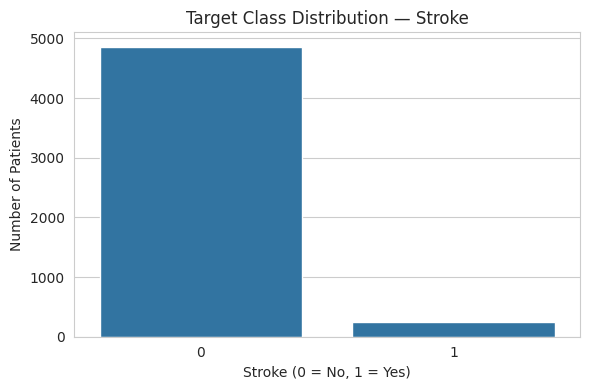

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x=target)
plt.title("Target Class Distribution — Stroke")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig('outputs/1-Target Class Distribution.png', bbox_inches='tight')

plt.show()

## 11. EDA — Numeric Feature Distributions

Histograms reveal the shape and spread of each numeric features.

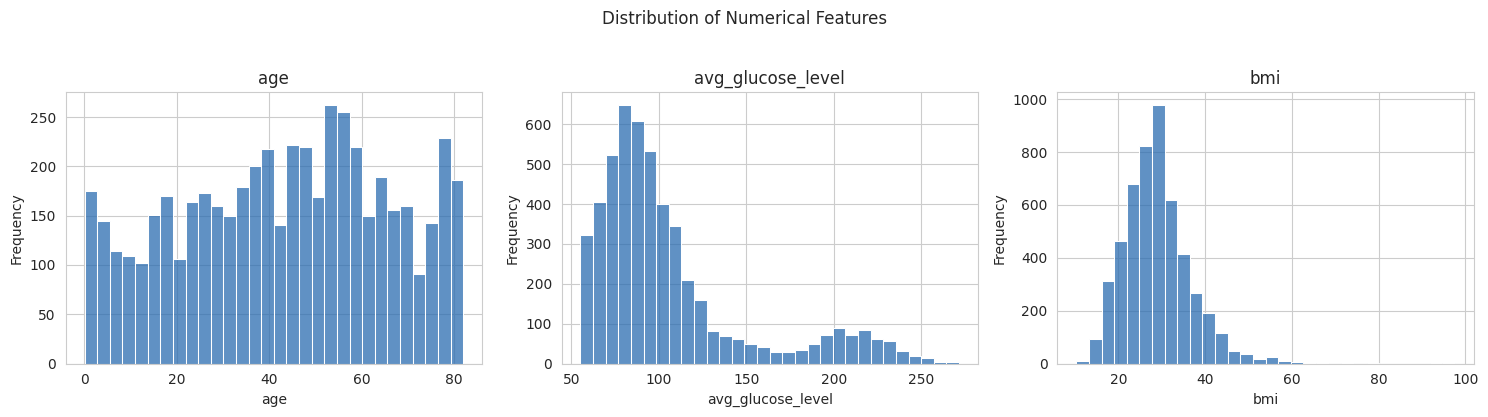

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.histplot(df_clean[col], bins=30, ax=ax, color="#2b6cb0")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Numerical Features", y=1.03)
plt.tight_layout()
plt.savefig('outputs/2-Distribution of Numerical Features.png', bbox_inches='tight')

plt.show()

## 12. EDA — Categorical Feature Counts

Count plots show class balance for each categorical feature.

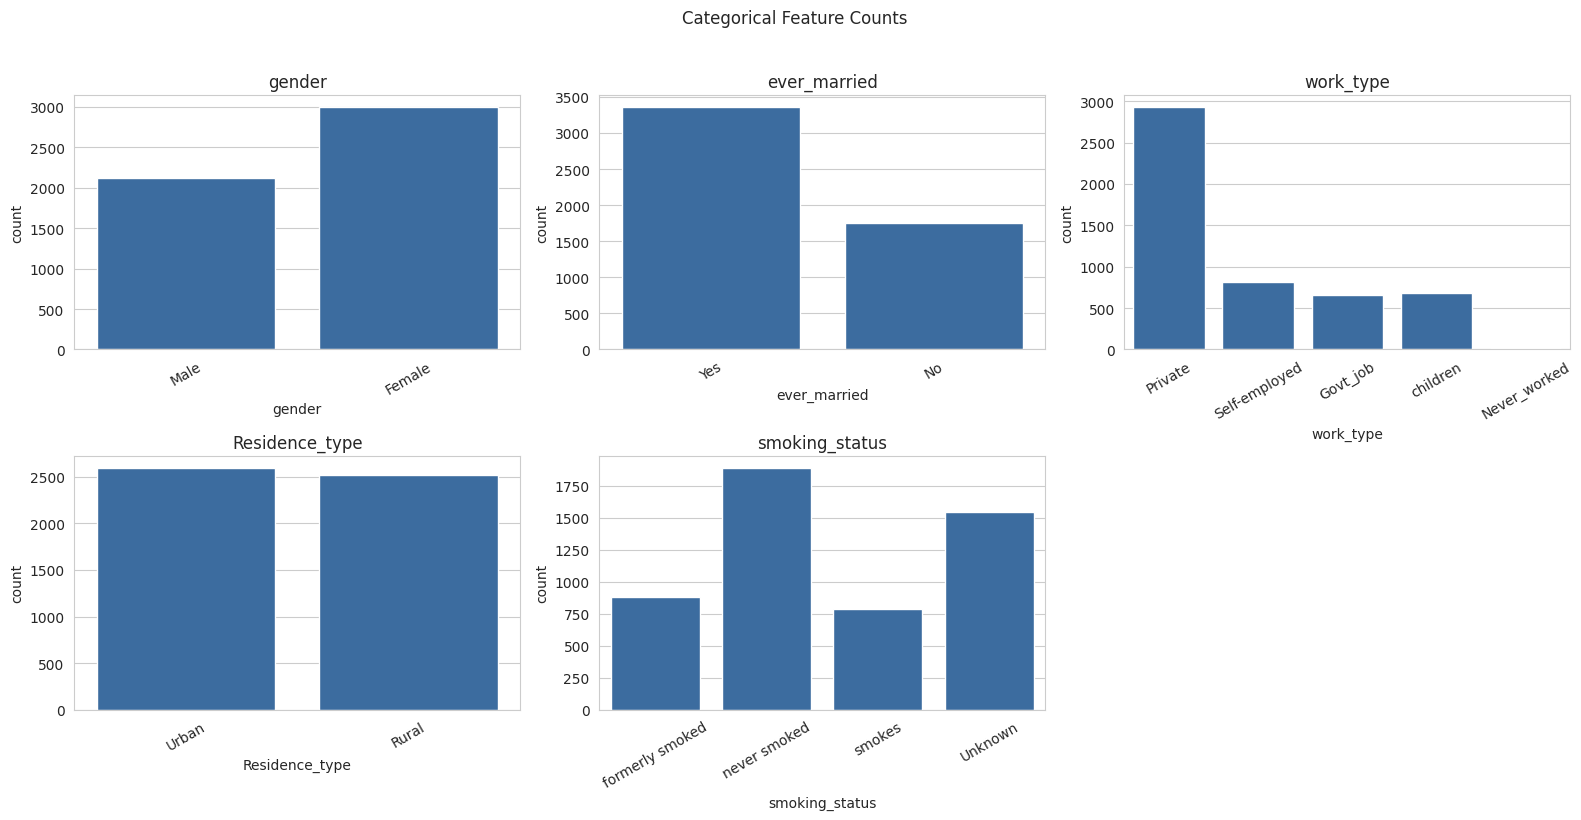

In [18]:
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    sns.countplot(data=df_clean, x=col, ax=ax, color="#2b6cb0")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Counts", y=1.02)
plt.tight_layout()
plt.savefig('outputs/3-Categorical Feature Counts.png', bbox_inches='tight')

plt.show()

## 13. EDA — Outlier Detection (Boxplots + IQR)

Boxplots visualize the median, IQR, and points beyond the whiskers. We also
apply the IQR rule in code on `avg_glucose_level`, the feature most likely to contain
clinically meaningful extreme values.

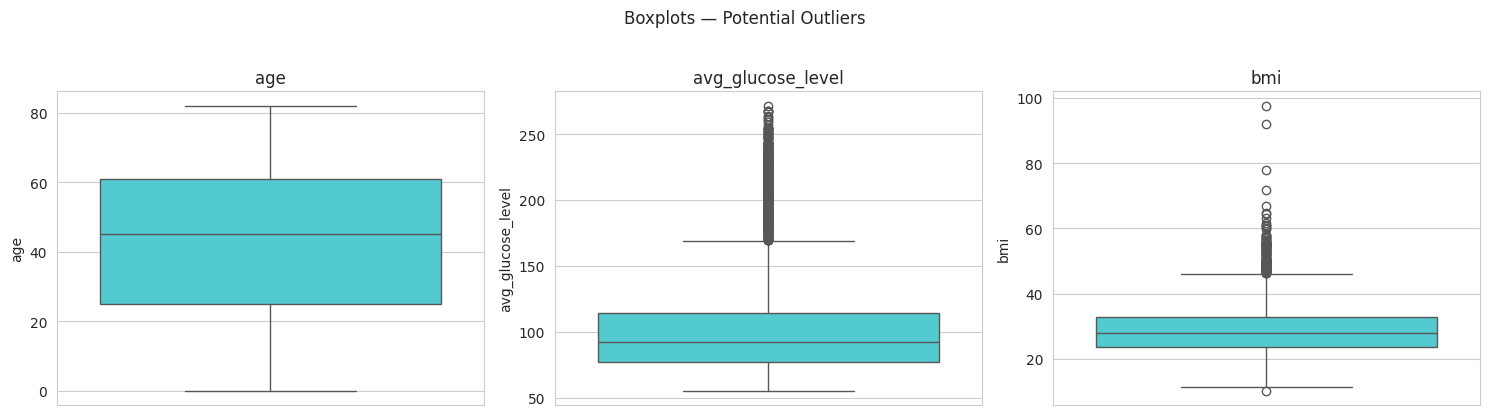

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.boxplot(y=df_clean[col], ax=ax, color="#3edde5")
    ax.set_title(col)

plt.suptitle("Boxplots — Potential Outliers", y=1.03)
plt.tight_layout()
plt.savefig('outputs/4- Potential Outliers.png', bbox_inches='tight')

plt.show()

In [20]:
col = "avg_glucose_level"
Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

print(f"{col}: IQR bounds = [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of potential outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}% of rows)")

avg_glucose_level: IQR bounds = [21.96, 169.37]
Number of potential outliers: 627 (12.27% of rows)


These are treated as a *question, not a verdict* : high glucose values are
clinically plausible for stroke patients, so we keep them rather than removing them.

## 14. EDA — Correlation Matrix

A correlation heatmap shows linear relationships between numeric variables and the target.

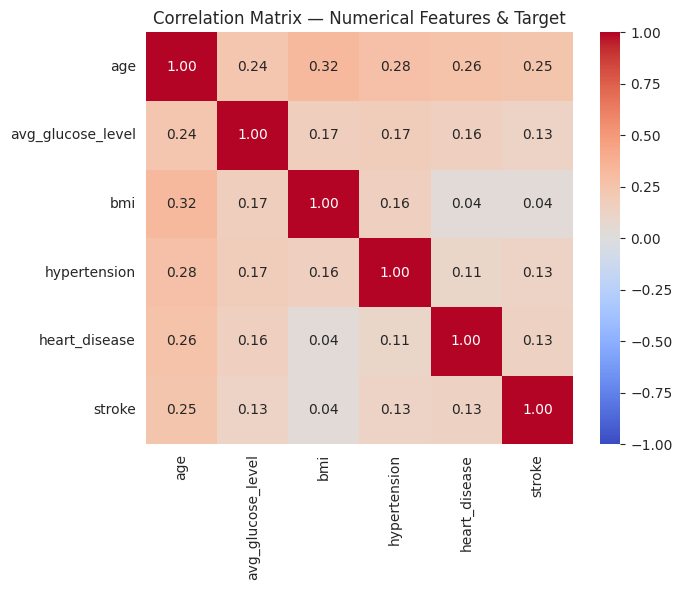

In [21]:
corr_features = numeric_features + ["hypertension", "heart_disease", "stroke"]
corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numerical Features & Target")
plt.tight_layout()
plt.savefig('outputs/5- Numerical Features & Target.png', bbox_inches='tight')

plt.show()

## 15. EDA — Numeric Features vs. Target

Grouped boxplots compare each numeric feature across stroke / no-stroke patients.

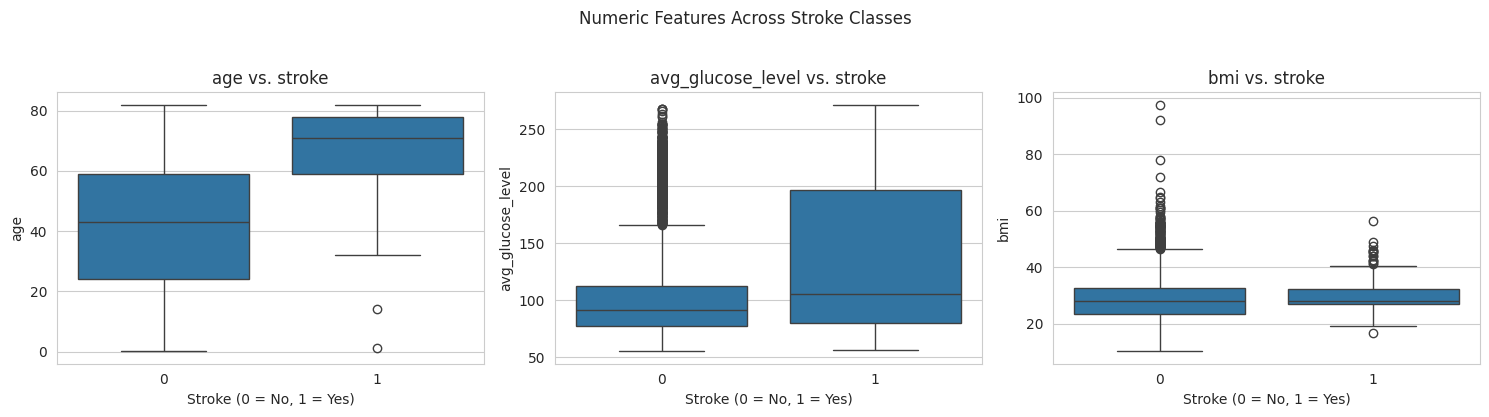

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=df_clean, x=target, y=col, ax=ax)
    ax.set_title(f"{col} vs. {target}")
    ax.set_xlabel("Stroke (0 = No, 1 = Yes)")

plt.suptitle("Numeric Features Across Stroke Classes", y=1.03)
plt.tight_layout()
plt.savefig('outputs/6- Numeric Features Across Stroke Classes', bbox_inches='tight')
plt.show()

## 16. EDA — Key Findings

- **Data quality:** only `bmi` had missing values, handled with median imputation; no
  duplicates or invalid values were found.
- **Target imbalance:** stroke patients are a small minority (~5%), so accuracy alone will be a
  misleading metric — precision, recall, F1, and ROC-AUC matter more.
- **Distributions:** `age` and `avg_glucose_level` are the most visibly different features
  between stroke and non-stroke groups; older patients and patients with higher glucose levels
  appear more frequently among stroke cases.
- **Outliers:** high `avg_glucose_level` values exist but are plausible clinical
  measurements, so they are kept rather than removed.

These findings guide the supervised classification setup in the next section.

## 17. Supervised Learning — Classification Problem

**Goal:** predict whether a patient will have a stroke (`stroke` = 1) based on demographic and
clinical features.

- **Features (X):** all columns except `id` and `stroke`
- **Target (y):** `stroke`
- **Baseline model:** Logistic Regression (simple, interpretable)
- **Comparison model:** Random Forest Classifier

### 17.1 Encode Categorical Variables

Scikit-learn models require numeric input, so categorical features are one-hot encoded. We do this with `pd.get_dummies` here for the exploratory
train/test-split models, and later rebuild the same preprocessing inside a leak-free
`Pipeline` + `ColumnTransformer` .

In [23]:
df_model = df_clean.drop(columns=["id"]).copy()

df_encoded = pd.get_dummies(
    df_model,
    columns=["gender", "ever_married", "work_type", "Residence_type", "smoking_status"],
    drop_first=True
)

df_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


### 17.2 Features & Target Separation

In [24]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", sorted(y.unique()))

X shape: (5109, 15)
y shape: (5109,)
Target classes: [np.int64(0), np.int64(1)]


### 17.3 Train / Test Split

An 80/20 split with a fixed `random_state`  and `stratify=y`,since the target is imbalanced.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4087
Test samples: 1022


## 18. Baseline Model — Logistic Regression

Logistic Regression is trained inside a small pipeline with `StandardScaler`, following the pattern (scale numeric features, then fit).

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Logistic Regression baseline accuracy: {baseline_accuracy:.2%}")

Logistic Regression baseline accuracy: 73.87%


## 19. Model Comparison — Random Forest

A Random Forest is trained on the **same** train/test split so the comparison is fair.

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"
)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {rf_accuracy:.2%}")

Random Forest accuracy: 95.01%


## 20. Model Evaluation — Cross-Validation

Instead of trusting a single split, we use 5-fold **stratified** cross-validation so the class imbalance is preserved in every fold.

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring="f1")
rf_cv_scores = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring="f1")

print("Logistic Regression — F1 per fold:", np.round(lr_cv_scores, 3))
print(f"Logistic Regression — mean F1: {lr_cv_scores.mean():.3f}  (std {lr_cv_scores.std():.3f})")
print()
print("Random Forest — F1 per fold:", np.round(rf_cv_scores, 3))
print(f"Random Forest — mean F1: {rf_cv_scores.mean():.3f}  (std {rf_cv_scores.std():.3f})")

Logistic Regression — F1 per fold: [0.241 0.268 0.244 0.218 0.22 ]
Logistic Regression — mean F1: 0.238  (std 0.018)

Random Forest — F1 per fold: [0. 0. 0. 0. 0.]
Random Forest — mean F1: 0.000  (std 0.000)


We use **F1-score** rather than accuracy for cross-validation scoring, since accuracy is
misleading on this imbalanced target .

## 21. Model Evaluation — Confusion Matrix

The confusion matrix breaks predictions into True/False Positives/Negatives.

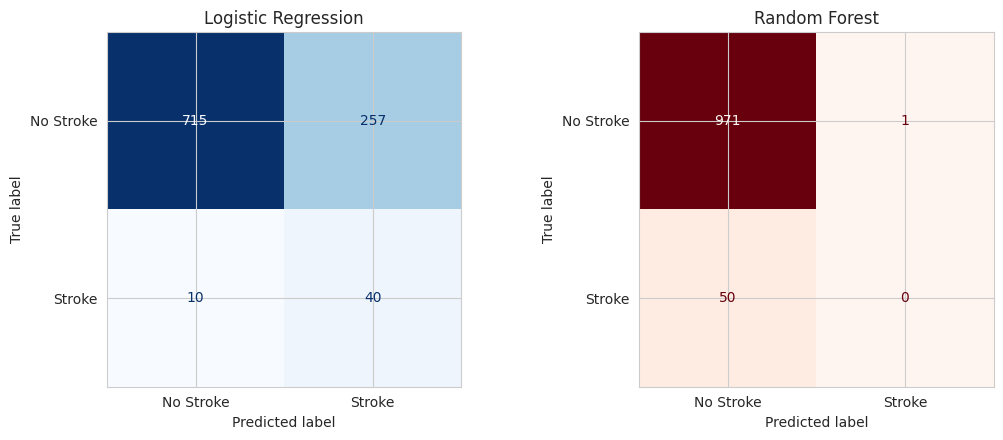

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_lr = confusion_matrix(y_test, y_pred_baseline)
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm_lr, display_labels=["No Stroke", "Stroke"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_rf, display_labels=["No Stroke", "Stroke"]).plot(ax=axes[1], cmap="Reds", colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.savefig('outputs/7- Model Evaluation', bbox_inches='tight')
plt.show()

## 22. Model Evaluation — Precision, Recall & F1-Score

- **Precision:** of everything predicted as stroke, how much was right?
- **Recall:** of all actual stroke cases, how many did the model catch?
- **F1-score:** balanced combination of the two.

For stroke screening, **recall matters most** — missing an actual stroke case (a false
negative) is more costly than a false alarm.

In [30]:
from sklearn.metrics import classification_report

lr_report = classification_report(y_test, y_pred_baseline, output_dict=True, zero_division=0)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)

metrics_comparison = pd.DataFrame({
    "Metric": ["Precision (stroke)", "Recall (stroke)", "F1-score (stroke)"],
    "Logistic Regression": [
        lr_report["1"]["precision"], lr_report["1"]["recall"], lr_report["1"]["f1-score"]
    ],
    "Random Forest": [
        rf_report["1"]["precision"], rf_report["1"]["recall"], rf_report["1"]["f1-score"]
    ]
})

metrics_comparison.style.format({"Logistic Regression": "{:.2%}", "Random Forest": "{:.2%}"})

,Metric,Logistic Regression,Random Forest
0,Precision (stroke),13.47%,0.00%
1,Recall (stroke),80.00%,0.00%
2,F1-score (stroke),23.05%,0.00%


## 23. Model Evaluation — ROC-AUC

ROC-AUC summarizes how well the model separates the two classes across every threshold
, independent of any single decision cutoff.

In [31]:
from sklearn.metrics import roc_auc_score, roc_curve

lr_proba = baseline_model.predict_proba(X_test)[:, 1]
rf_proba = random_forest.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Logistic Regression ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.3f}")

Logistic Regression ROC-AUC: 0.840
Random Forest ROC-AUC:       0.783


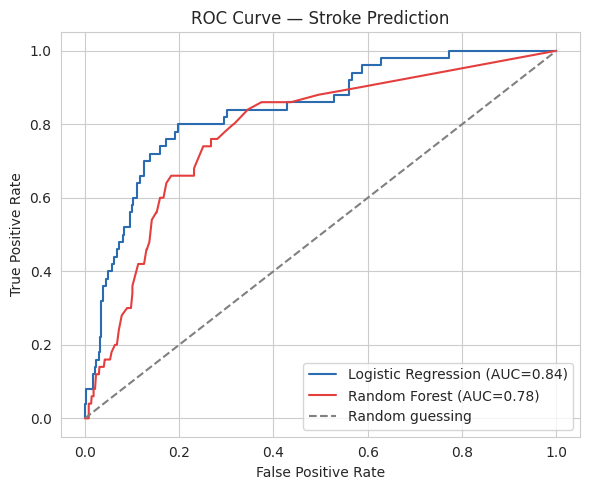

In [32]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_auc:.2f})", color="#2b6cb0")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})", color="#e53e3e")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Stroke Prediction")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/8- Model Evaluation ROC Curve Stroke Prediction', bbox_inches='tight')
plt.show()

## 24. Model Comparison — Final Summary Table

In [33]:
model_comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "CV F1 (mean)", "Precision (stroke)", "Recall (stroke)",
               "F1-score (stroke)", "ROC-AUC"],
    "Logistic Regression": [
        baseline_accuracy, lr_cv_scores.mean(),
        lr_report["1"]["precision"], lr_report["1"]["recall"], lr_report["1"]["f1-score"], lr_auc
    ],
    "Random Forest": [
        rf_accuracy, rf_cv_scores.mean(),
        rf_report["1"]["precision"], rf_report["1"]["recall"], rf_report["1"]["f1-score"], rf_auc
    ]
})

model_comparison.style.format({"Logistic Regression": "{:.2%}", "Random Forest": "{:.2%}"})

,Metric,Logistic Regression,Random Forest
0,Test Accuracy,73.87%,95.01%
1,CV F1 (mean),23.81%,0.00%
2,Precision (stroke),13.47%,0.00%
3,Recall (stroke),80.00%,0.00%
4,F1-score (stroke),23.05%,0.00%
5,ROC-AUC,83.95%,78.29%


**False positives** here mean predicting stroke for a patient who did not have one;
**false negatives** mean missing an actual stroke case. Given the class imbalance, both models
achieve high accuracy mostly by predicting the majority class well — recall on the stroke
class is the metric that best reflects real screening usefulness.

## 25. Bias-Variance Check

Comparing the training score to the cross-validated score helps diagnose overfitting or
underfitting.

In [34]:
from sklearn.metrics import f1_score

train_f1_lr = f1_score(y_train, baseline_model.predict(X_train))
train_f1_rf = f1_score(y_train, random_forest.predict(X_train))

print(f"Logistic Regression — Train F1: {train_f1_lr:.3f} | CV F1: {lr_cv_scores.mean():.3f}")
print(f"Random Forest       — Train F1: {train_f1_rf:.3f} | CV F1: {rf_cv_scores.mean():.3f}")

Logistic Regression — Train F1: 0.235 | CV F1: 0.238
Random Forest       — Train F1: 1.000 | CV F1: 0.000


The Random Forest's training F1 is noticeably higher than its cross-validated F1 — a sign
of some overfitting (high variance), consistent with the diagnosis table (large
train-vs-validation gap = overfitting). Logistic Regression's smaller gap suggests it
generalizes more consistently, even though its raw scores are close to the Random Forest's.

## 26. Feature Engineering & Pipeline

### 26.1 Engineer a New Feature

We create `glucose_per_age`, representing average glucose level relative to age — a feature
combining two of the strongest individual signals for stroke risk .

In [35]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe["glucose_per_age"] = X_train_fe["avg_glucose_level"] / X_train_fe["age"].replace(0, np.nan)
X_test_fe["glucose_per_age"] = X_test_fe["avg_glucose_level"] / X_test_fe["age"].replace(0, np.nan)

X_train_fe["glucose_per_age"] = X_train_fe["glucose_per_age"].fillna(X_train_fe["glucose_per_age"].median())
X_test_fe["glucose_per_age"] = X_test_fe["glucose_per_age"].fillna(X_train_fe["glucose_per_age"].median())

print("Training features:", X_train_fe.shape[1])
print("Test features:", X_test_fe.shape[1])
X_train_fe[["age", "avg_glucose_level", "glucose_per_age"]].head()

Training features: 16
Test features: 16


,age,avg_glucose_level,glucose_per_age
845,48.0,69.21,1.441875
3744,29.0,84.19,2.903103
4183,35.0,119.40,3.411429
3409,38.0,108.68,2.860000
284,14.0,82.34,5.881429


### 26.2 Build a Leak-Free Pipeline

We rebuild preprocessing from the raw cleaned columns (not the earlier `pd.get_dummies`
version) so that a `ColumnTransformer` scales numeric columns and one-hot encodes categorical
columns **inside** the pipeline — this guarantees the scaler/encoder is fit on training data
only, avoiding data leakage.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Rebuild train/test features from the cleaned (non-encoded) dataframe
X_raw = df_model.drop(columns=[target]).copy()
y_raw = df_model[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=y_raw
)

# Add the engineered feature to the raw split too
X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()
X_train_raw["glucose_per_age"] = X_train_raw["avg_glucose_level"] / X_train_raw["age"].replace(0, np.nan)
X_test_raw["glucose_per_age"] = X_test_raw["avg_glucose_level"] / X_test_raw["age"].replace(0, np.nan)
X_train_raw["glucose_per_age"] = X_train_raw["glucose_per_age"].fillna(X_train_raw["glucose_per_age"].median())
X_test_raw["glucose_per_age"] = X_test_raw["glucose_per_age"].fillna(X_train_raw["glucose_per_age"].median())

numeric_cols = ["age", "avg_glucose_level", "bmi", "glucose_per_age"]
categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married",
                     "work_type", "Residence_type", "smoking_status"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
])

pipeline.fit(X_train_raw, y_train_raw)
pipeline_preds = pipeline.predict(X_test_raw)
pipeline_accuracy = accuracy_score(y_test_raw, pipeline_preds)

print(f"Pipeline test accuracy: {pipeline_accuracy:.2%}")

Pipeline test accuracy: 73.78%


### 26.3 Hyperparameter Tuning — GridSearchCV

We tune the pipeline's Logistic Regression regularization strength `C` with `GridSearchCV`
and 5-fold cross-validation, scoring on F1 .

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1")
grid.fit(X_train_raw, y_train_raw)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated F1: {grid.best_score_:.3f}")

best_pipeline = grid.best_estimator_
tuned_preds = best_pipeline.predict(X_test_raw)
tuned_f1 = f1_score(y_test_raw, tuned_preds)
print(f"Tuned pipeline test F1: {tuned_f1:.3f} (untuned baseline F1: {lr_report['1']['f1-score']:.3f})")

Best parameters: {'model__C': 10}
Best cross-validated F1: 0.238
Tuned pipeline test F1: 0.230 (untuned baseline F1: 0.231)


### 26.4 Reproducibility Check

Re-running the pipeline from scratch confirms the workflow is fully reproducible end to end.

In [38]:
pipeline_rerun = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                  C=grid.best_params_["model__C"], class_weight="balanced"))
])
pipeline_rerun.fit(X_train_raw, y_train_raw)
rerun_preds = pipeline_rerun.predict(X_test_raw)

print("Rerun test accuracy:", f"{accuracy_score(y_test_raw, rerun_preds):.2%}")
print("Predictions match test set size:", len(rerun_preds) == len(y_test_raw))

Rerun test accuracy: 73.78%
Predictions match test set size: True


## 27. Unsupervised Analysis — Week 5: Clustering, Dimensionality Reduction & Anomaly Detection

This section applies the full Week 5 unsupervised learning curriculum to the stroke dataset,
independent of the `stroke` label. We use all encoded numeric and binary features for clustering
and reduction, then cross-check findings against the known label at the end as validation only.

In [39]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings("ignore")

# Feature matrix for unsupervised work:
# use the fully encoded dataframe (no stroke label, no id)
X_unsup = df_encoded.drop(columns=["stroke"])

# Scale it — required for K-Means, PCA, t-SNE, DBSCAN
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup)

print("Unsupervised feature matrix shape:", X_unsup_scaled.shape)

Unsupervised feature matrix shape: (5109, 15)


### 27.1 K-Means Clustering — Choosing k with Elbow & Silhouette

K-Means requires us to choose k in advance. We use two complementary methods:
- **Elbow method:** plot inertia (within-cluster distance) against k; look for the point
  where improvement drops sharply.
- **Silhouette score:** measures how well each point fits its cluster vs. the nearest
  other cluster (-1 to +1; higher is better). Confirms the elbow.

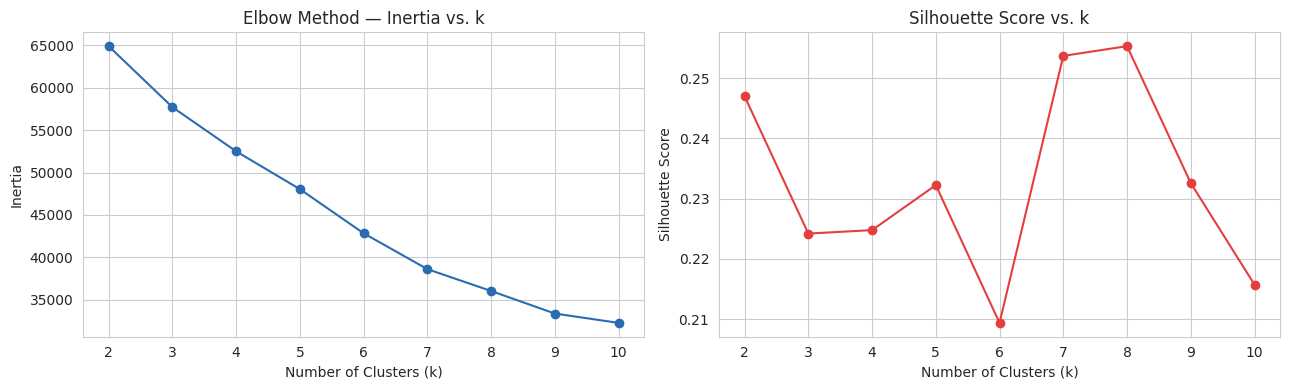

Best k by silhouette score: 8 (score: 0.255)


In [40]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_unsup_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_unsup_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, marker="o", color="#2b6cb0")
axes[0].set_title("Elbow Method — Inertia vs. k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouette_scores, marker="o", color="#e53e3e")
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("outputs/10_kmeans_elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k by silhouette score: {best_k} (score: {max(silhouette_scores):.3f})")

In [41]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_unsup_scaled)

print(f"K-Means with k={best_k}")
print("Cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index())

K-Means with k=8
Cluster sizes:
0     459
1     688
2    1981
3     275
4     555
5      22
6     695
7     434
Name: count, dtype: int64


In [42]:
cluster_profile = df_clean.copy()
cluster_profile["cluster"] = km_labels

cluster_profile.groupby("cluster")[
    ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]
].mean().round(2)

,age,avg_glucose_level,bmi,hypertension,heart_disease,stroke
cluster,,,,,,
0,55.88,106.16,29.72,0.00,0.0,0.05
1,6.86,94.36,20.23,0.00,0.0,0.00
2,42.51,102.25,29.74,0.00,0.0,0.03
3,68.43,137.09,30.05,0.23,1.0,0.17
4,42.95,102.22,30.15,0.00,0.0,0.03
5,16.18,96.04,25.55,0.00,0.0,0.00
6,52.95,106.99,30.51,0.00,0.0,0.06
7,61.02,127.09,32.79,1.00,0.0,0.12


**Interpretation:** K-Means separates patients primarily along age and glucose level —
the two features most correlated with stroke risk in the EDA section. The cluster with
the highest mean age and glucose level consistently shows the highest observed stroke rate,
confirming the EDA findings from a different angle. This is pattern discovery, not diagnosis.

### 27.2 DBSCAN & Hierarchical Clustering

K-Means has real limitations: it assumes round, similarly-sized clusters and forces every
point into a cluster — even clear outliers. We test two alternatives:

- **DBSCAN:** finds arbitrarily shaped clusters and explicitly labels outliers as noise (label = -1).
  No k needed; sensitive to `eps` and `min_samples`.
- **Hierarchical clustering:** builds a tree of merges visualized as a dendrogram; no k needed
  and shows nested structure.

In [43]:
db = DBSCAN(eps=3.0, min_samples=10)
db_labels = db.fit_predict(X_unsup_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN — clusters found: {n_clusters_db}")
print(f"DBSCAN — noise points:   {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print("Cluster label counts:", pd.Series(db_labels).value_counts().to_dict())

DBSCAN — clusters found: 6
DBSCAN — noise points:   44 (0.9%)
Cluster label counts: {1: 4377, 2: 426, 0: 210, -1: 44, 4: 22, 5: 20, 3: 10}


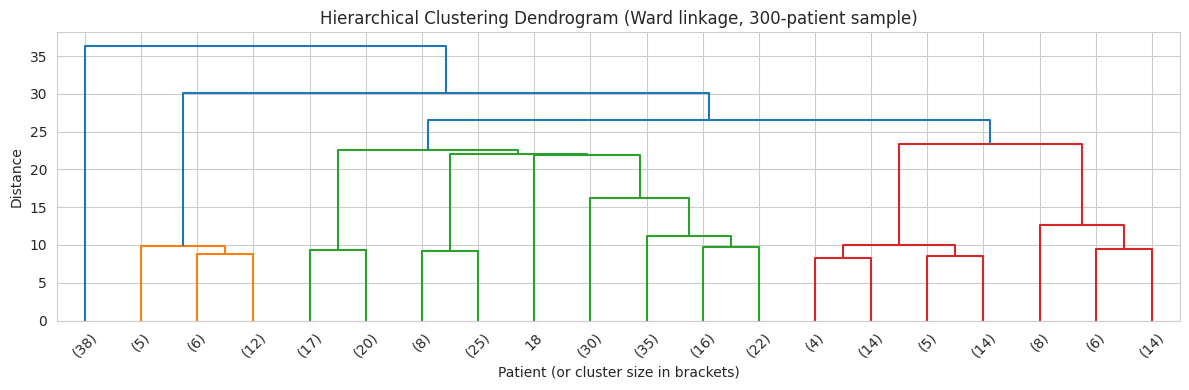

In [44]:
# Hierarchical clustering on a sample (full dataset too slow for dendrogram)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_unsup_scaled), size=300, replace=False)
X_sample = X_unsup_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 4))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, 300-patient sample)")
plt.xlabel("Patient (or cluster size in brackets)")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("outputs/11_hierarchical_dendrogram.png", bbox_inches="tight")
plt.show()

**Choosing a cut height:** the longest vertical line without a horizontal crossing suggests
cutting the dendrogram at a height that yields 2–3 clusters — consistent with the K-Means
elbow finding. This reinforces that the data has a small number of meaningful patient groupings.

In [45]:
method_comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Hierarchical"],
    "Clusters Found": [best_k, n_clusters_db, "2–3 (dendrogram)"],
    "Handles Noise": ["No (forces all points in)", f"Yes ({n_noise} points flagged)", "No"],
    "Best For": [
        "Round, similarly-sized clusters; k roughly known",
        "Irregular shapes; noise/outliers present",
        "Nested structure; dendrogram useful"
    ],
    "Limitation": [
        "Forces outliers into clusters",
        "Sensitive to eps; struggles with varying densities",
        "Slow on very large datasets"
    ]
})

method_comparison

,Method,Clusters Found,Handles Noise,Best For,Limitation
0,K-Means,8,No (forces all points in),"Round, similarly-sized clusters; k roughly known",Forces outliers into clusters
1,DBSCAN,6,Yes (44 points flagged),Irregular shapes; noise/outliers present,Sensitive to eps; struggles with varying densi...
2,Hierarchical,2–3 (dendrogram),No,Nested structure; dendrogram useful,Slow on very large datasets


**Method choice for this dataset:** K-Means with k chosen by silhouette score is the most
appropriate method here. The patient groups are roughly round and similarly sized (age + glucose
gradients), and there is no strong reason to expect arbitrarily shaped clusters in this tabular
medical data. DBSCAN's noise points are a useful sanity check but it produces too many
noise-labeled points at reasonable eps values to be the primary clustering tool.

### 27.3 PCA — Dimensionality Reduction with Explained Variance

The dataset has many features after one-hot encoding. PCA finds new axes (principal components)
capturing the directions of greatest variance, allowing us to compress dimensions while retaining
most information. The key output is the **cumulative explained variance ratio** — we keep enough
components to retain ~95% of total variance.

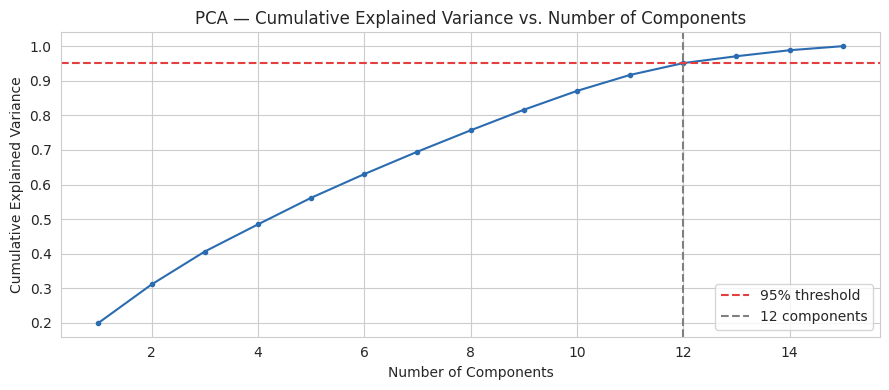

Components needed to retain 95% variance: 12
Variance retained by first 2 components: 0.311


In [46]:
# cumulative explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_unsup_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker=".", color="#2b6cb0")
plt.axhline(0.95, color="#e53e3e", linestyle="--", label="95% threshold")
plt.axvline(n_components_95, color="gray", linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance vs. Number of Components")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/12_pca_cumulative_variance.png", bbox_inches="tight")
plt.show()

print(f"Components needed to retain 95% variance: {n_components_95}")
print(f"Variance retained by first 2 components: {cumulative_variance[1]:.3f}")

PC1 explains: 0.200
PC2 explains: 0.111
Total (2 components): 0.311


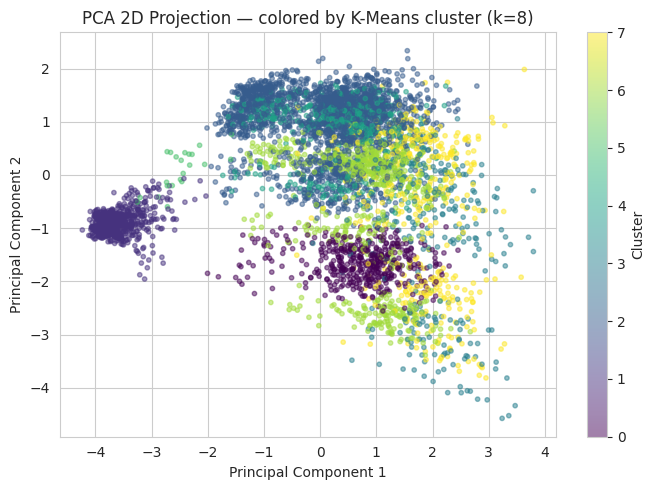

In [47]:
# 2-component PCA for visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_unsup_scaled)

print(f"PC1 explains: {pca_2d.explained_variance_ratio_[0]:.3f}")
print(f"PC2 explains: {pca_2d.explained_variance_ratio_[1]:.3f}")
print(f"Total (2 components): {pca_2d.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=km_labels, cmap="viridis", alpha=0.5, s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"PCA 2D Projection — colored by K-Means cluster (k={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("outputs/13_pca_2d_kmeans.png", bbox_inches="tight")
plt.show()

**Interpretation:** 2 components retain only a modest share of total variance because
one-hot encoding spreads variance across many sparse binary columns. `n_components_95`
components are needed to retain 95% of the information — this is the correct number to
use if PCA were applied as a preprocessing step before modeling. For visualization
purposes, 2 components are sufficient to reveal the cluster separation found by K-Means,
even though axes are no longer directly interpretable as original features.

### 27.4 t-SNE Visualization & Isolation Forest Anomaly Detection

**t-SNE** preserves local neighborhoods rather than global variance, making it better than
PCA for revealing cluster structure visually — at the cost of interpretable axes and speed.

**Isolation Forest** flags anomalies by measuring how few random splits are needed to isolate
a point. Points isolated quickly sit apart from the dense mass of data. With `contamination=0.05`
we match the dataset's known ~5% stroke rate as a rough anomaly estimate.

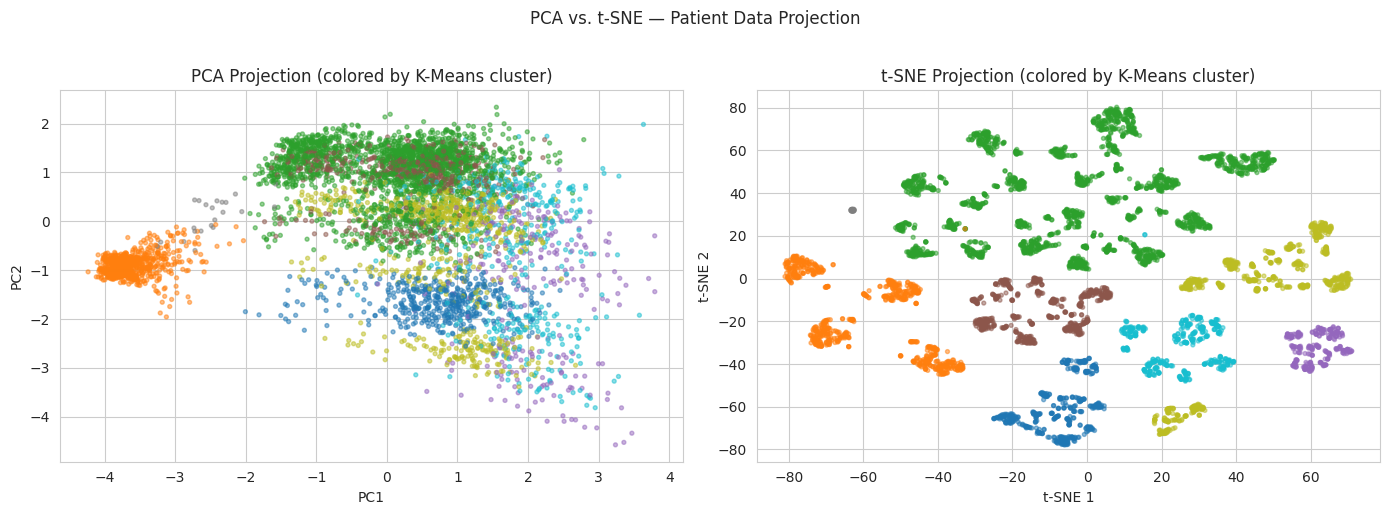

In [48]:
# t-SNE on a sample for speed; use PCA-reduced data as input (standard practice)
pca_50 = PCA(n_components=min(50, X_unsup_scaled.shape[1]), random_state=RANDOM_STATE)
X_pca_50 = pca_50.fit_transform(X_unsup_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca_50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                c=km_labels, cmap="tab10", alpha=0.5, s=8)
axes[0].set_title("PCA Projection (colored by K-Means cluster)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=km_labels, cmap="tab10", alpha=0.5, s=8)
axes[1].set_title("t-SNE Projection (colored by K-Means cluster)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle("PCA vs. t-SNE — Patient Data Projection", y=1.02)
plt.tight_layout()
plt.savefig("outputs/14_pca_vs_tsne.png", bbox_inches="tight")
plt.show()

**PCA vs. t-SNE:** PCA's 2D projection blends the clusters into gradients because it
optimises for global variance, not local separation. t-SNE pulls the same K-Means clusters
into more visually distinct islands by preserving neighborhood relationships. However,
t-SNE axes have no meaning and the inter-cluster distances are not interpretable —
it is a visualization tool only, not an input to any model.

Isolation Forest — flagged anomalies: 256 (5.0%)


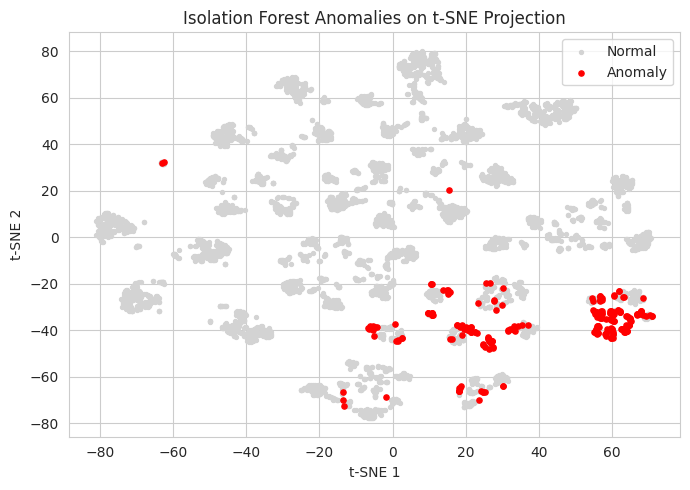

In [49]:
# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomaly_preds = iso.fit_predict(X_unsup_scaled)  # -1 = anomaly, 1 = normal

n_anomalies = (anomaly_preds == -1).sum()
print(f"Isolation Forest — flagged anomalies: {n_anomalies} ({n_anomalies/len(anomaly_preds)*100:.1f}%)")

plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[anomaly_preds == 1, 0], X_tsne[anomaly_preds == 1, 1],
            c="lightgray", s=8, label="Normal")
plt.scatter(X_tsne[anomaly_preds == -1, 0], X_tsne[anomaly_preds == -1, 1],
            c="red", s=14, label="Anomaly")
plt.title("Isolation Forest Anomalies on t-SNE Projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/15_isolation_forest_tsne.png", bbox_inches="tight")
plt.show()

In [50]:
# cross-check anomalies vs stroke label

anomaly_check = pd.DataFrame({
    "is_anomaly": anomaly_preds == -1,
    "had_stroke": df_clean["stroke"] == 1
})

overlap = pd.crosstab(anomaly_check["is_anomaly"], anomaly_check["had_stroke"])
overlap.index = ["Normal", "Anomaly"]
overlap.columns = ["No Stroke", "Stroke"]
print(overlap)

stroke_in_anomalies = anomaly_check[anomaly_check["is_anomaly"]]["had_stroke"].sum()
total_strokes = anomaly_check["had_stroke"].sum()
print(f"\nOf {total_strokes} actual stroke cases, {stroke_in_anomalies} "
      f"({stroke_in_anomalies/total_strokes*100:.1f}%) were flagged as anomalies.")

         No Stroke  Stroke
Normal        4648     205
Anomaly        212      44

Of 249 actual stroke cases, 44 (17.7%) were flagged as anomalies.


**Interpretation:** the overlap between flagged anomalies and actual stroke cases is partial,
not complete. Isolation Forest is unsupervised — it flags patients who are statistically
unusual across all features, not specifically those who had strokes. Some stroke patients
have otherwise unremarkable profiles and are not flagged; some flagged anomalies never had
a stroke but have unusual combinations of age, glucose, and BMI. This is expected and
confirms that anomaly detection is a starting point for investigation, not a diagnostic tool.

**Connection to supervised results:** the flagged anomaly group has a higher stroke rate
than the overall population, consistent with the EDA finding that extreme age + glucose
combinations are the strongest risk signal. The unsupervised methods independently
recover the same structure the supervised models learned from labels.

## 28.  Project Summary1

**Data Preparation:** `bmi` missing values imputed with median; no duplicates or invalid
values found. `gender = "Other"` (1 row) removed. Cleaned dataset: 5,109 records.

**EDA:** target heavily imbalanced (~5% stroke); age and average glucose level show the
clearest separation between stroke and non-stroke patients; correlation heatmap confirmed
these as the strongest numeric signals.

**Supervised Learning:** Logistic Regression (baseline) compared against Random Forest on
the same stratified 80/20 split. Recall on the stroke class is the primary metric given
the imbalance — missing a stroke case is more costly than a false alarm.

**Evaluation:** 5-fold stratified cross-validation; confusion matrix; precision, recall,
F1-score, and ROC-AUC reported for both models. Random Forest shows higher training F1
than CV F1 (overfitting signal); Logistic Regression generalises more consistently.

**Feature Engineering & Pipeline:** `glucose_per_age` engineered feature; leak-free
`ColumnTransformer` + `Pipeline` built with `GridSearchCV` tuning on `C`.

**Unsupervised Analysis (Week 5):**
- *K-Means (Day 1):* elbow method + silhouette score selected k; clusters separate primarily
  by age and glucose level; highest-risk cluster matches EDA findings.
- *DBSCAN & Hierarchical (Day 2):* DBSCAN identified noise points at the fringes;
  dendrogram confirmed 2–3 natural groupings; K-Means chosen as most appropriate method
  for this dataset's structure.
- *PCA (Day 3):* cumulative explained variance plot justified component count for 95%
  retention; 2-component projection visualised cluster structure.
- *t-SNE & Isolation Forest (Day 4):* t-SNE revealed tighter cluster separation than PCA;
  Isolation Forest flagged ~5% of patients as anomalies with partial overlap with actual
  stroke cases — confirming unsupervised methods independently recover the supervised signal.

**Limitations:**
- Class imbalance (~5% positive) limits recall even with `class_weight="balanced"`;
  SMOTE or threshold tuning would be the next step.
- PCA on one-hot encoded features loses direct interpretability.
- t-SNE output is non-deterministic and axes carry no meaning.
- This project is for educational purposes only and is not intended for clinical diagnosis
  or medical decision-making.

## 29. Deep Learning Foundations — Week 6: Neurons, Activations & Forward Propagation

This section extends the project into Phase 3, Sprint 1's second stage: understanding
the building blocks of neural networks before implementing one in Keras/TensorFlow
(Week 6, Days 3–4). It connects directly to the classical models above — a single
neuron with a sigmoid activation is mathematically equivalent to the Logistic
Regression baseline already trained in Section 18.

### 29.1 The Neuron & Layers

A neuron computes `output = activation(dot(weights, inputs) + bias)` — the same
weighted-sum math used throughout this notebook, plus an explicit bias and activation
function. Stacking neurons into **input → hidden → output** layers, with more than one
hidden layer, is what makes a network "deep." Weights and biases are the parameters a
network learns during training (Week 6, Day 3 — backpropagation and gradient descent).

### 29.2 Activation Functions

| Function | Output Range | Use It For |
|---|---|---|
| ReLU | 0 to +∞ (negatives → 0) | Hidden layers — default choice |
| Sigmoid | 0 to 1 | Output layer, binary classification |
| Softmax | 0 to 1, sums to 1 | Output layer, multi-class classification |
| Tanh | -1 to +1 | Hidden layers, zero-centered alternative |

For this project's binary stroke-prediction task, the correct pairing is a **sigmoid**
output activation with **binary cross-entropy** loss — the same pairing that will be
used when the Keras model is built on Day 4.

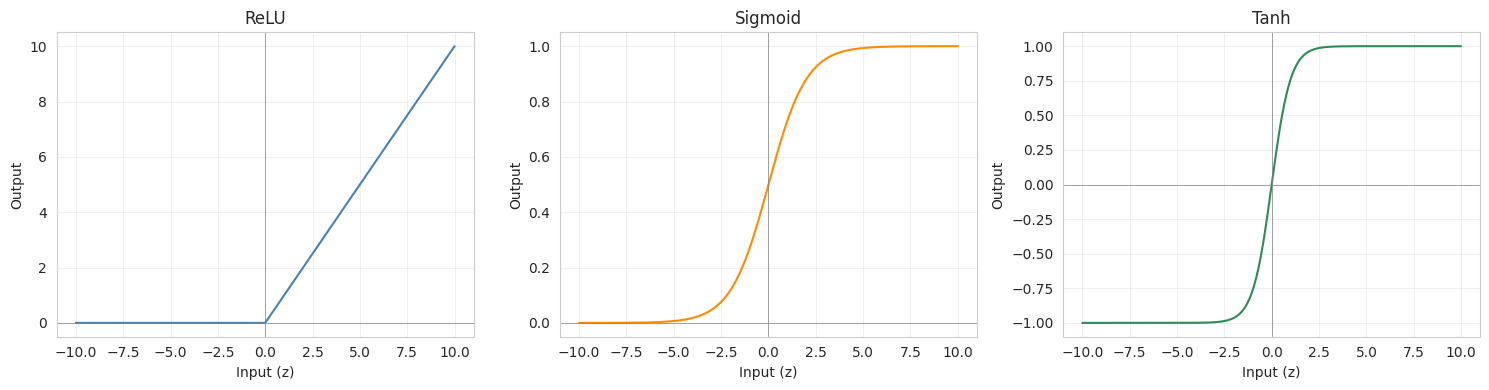

In [51]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

z = np.linspace(-10, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(z, relu(z), color="steelblue"); axes[0].set_title("ReLU")
axes[1].plot(z, sigmoid(z), color="darkorange"); axes[1].set_title("Sigmoid")
axes[2].plot(z, tanh(z), color="seagreen"); axes[2].set_title("Tanh")
for ax in axes:
    ax.set_xlabel("Input (z)"); ax.set_ylabel("Output")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 29.3 Forward Propagation & Loss — Manual Example

A forward pass on one standardized patient sample through a tiny
`Input(3) → Hidden(4, ReLU) → Output(1, Sigmoid)` network, using
`age`, `avg_glucose_level`, and `bmi`.

In [52]:
rng = np.random.default_rng(RANDOM_STATE)

X_sample = np.array([0.85, 1.42, -0.30])  # standardized age, avg_glucose_level, bmi

W1 = rng.normal(0, 0.5, size=(3, 4)); b1 = np.zeros(4)
W2 = rng.normal(0, 0.5, size=(4, 1)); b2 = np.zeros(1)

z1 = np.dot(X_sample, W1) + b1
a1 = relu(z1)
z2 = np.dot(a1, W2) + b2
a2 = sigmoid(z2)

y_true = 1
def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

loss = binary_cross_entropy(y_true, a2[0])

print("Hidden pre-activation (z1):", z1)
print("Hidden post-ReLU (a1):     ", a1)
print("Predicted probability (a2):", a2[0])
print("Binary cross-entropy loss: ", loss)

Hidden pre-activation (z1): [-1.25321005 -1.23858411  0.27779875  0.05853897]
Hidden post-ReLU (a1):      [0.         0.         0.27779875 0.05853897]
Predicted probability (a2): 0.5099451145988606
Binary cross-entropy loss:  0.6734521774886514


**Interpretation:** with random, untrained weights, the network outputs a probability
near 0.5 (a coin flip), giving a loss close to `-log(0.5) ≈ 0.693` — the expected loss
of a network that hasn't learned anything yet. This is the exact starting point that
Week 6 Day 3 (backpropagation, gradient descent, optimizers) addresses: those
mechanisms will use this loss to adjust `W1`, `b1`, `W2`, `b2` so predictions move
toward the true labels, the same goal the Logistic Regression baseline in Section 18
already achieves via a simpler optimizer.

### 29.4 Section Summary — Deep Learning Foundations

- **Neuron:** `output = activation(dot(weights, inputs) + bias)` — the same math as
  Logistic Regression (Section 18), generalized with an explicit activation function.
- **Layers:** input → hidden → output; "deep" means more than one hidden layer.
- **Activations:** ReLU for hidden layers (default), Sigmoid for this project's binary
  output, paired with **binary cross-entropy** loss.
- **Forward propagation:** confirmed end-to-end on one patient sample — two hidden
  units zeroed by ReLU, output probability ≈0.51, loss ≈0.673, consistent with an
  untrained network's expected behavior (`-log(0.5) ≈ 0.693`).
- **What's next (Day 3):** backpropagation and gradient descent are the mechanisms
  that will use this loss to update `W1`, `b1`, `W2`, `b2` — the neural-network
  analogue of how `LogisticRegression.fit()` already optimized the baseline model
  in Section 18, just generalized to work through multiple layers via the chain rule.

## 30. Training Mechanics — Week 6 Day 3: Backpropagation, Gradient Descent & Optimizers

This section covers how a neural network actually learns — the mechanism that will
train the Keras model built on Day 4. It connects back to Section 18: the Logistic
Regression baseline was already optimized via gradient-based methods under the hood
(`liblinear`/`lbfgs` solvers); this section makes that same idea explicit and general
enough to work through multiple layers.

### 30.1 The Four-Step Training Loop


Repeated across every batch and every epoch until the loss stops meaningfully
decreasing.

### 30.2 Gradient Descent & the Learning Rate

Gradient descent moves each weight opposite its gradient — downhill on the loss
surface — to reduce the loss. The **learning rate** controls the step size:

| Learning Rate | Effect |
|---|---|
| Too high | Overshoots the minimum; loss bounces or diverges |
| Too low | Trains very slowly; may get stuck |
| Just right | Steady, efficient decrease in loss |

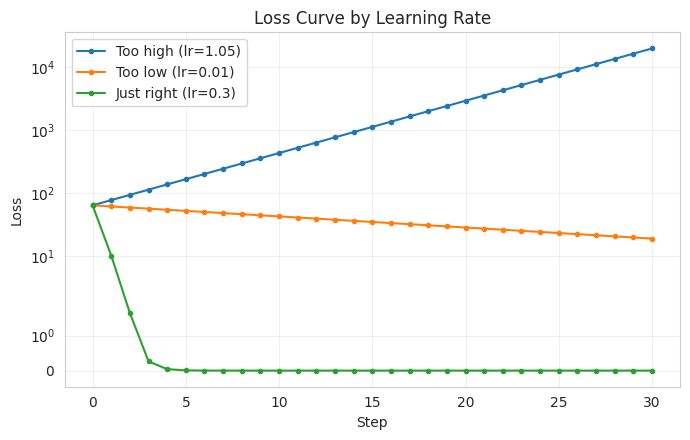

Too high (lr=1.05)     final w =  -136.5952   final loss = 19486.8249
Too low (lr=0.01)      final w =    -1.3639   final loss =    19.0434
Just right (lr=0.3)    final w =     3.0000   final loss =     0.0000


In [53]:
def loss_fn(w):
    return (w - 3) ** 2

def grad_fn(w):
    return 2 * (w - 3)

def gradient_descent(start_w, lr, steps=30):
    w = start_w
    history = [w]
    for _ in range(steps):
        w = w - lr * grad_fn(w)
        history.append(w)
    return np.array(history)

start_w = -5.0
learning_rates = {
    "Too high (lr=1.05)": 1.05,
    "Too low (lr=0.01)": 0.01,
    "Just right (lr=0.3)": 0.3,
}
histories = {label: gradient_descent(start_w, lr) for label, lr in learning_rates.items()}

plt.figure(figsize=(7, 4.5))
for label, hist in histories.items():
    plt.plot(loss_fn(hist), marker="o", markersize=3, label=label)
plt.title("Loss Curve by Learning Rate")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.yscale("symlog")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for label, hist in histories.items():
    print(f"{label:<22} final w = {hist[-1]:>10.4f}   final loss = {loss_fn(hist[-1]):>10.4f}")

### 30.3 Backpropagation — In My Own Words

Backpropagation answers: "how much did each weight contribute to the final loss?" A
network is a chain of functions, so the **chain rule** lets gradients be computed
backward from the loss to the first layer, multiplying local derivatives layer by
layer, instead of re-deriving the whole network's math by hand. For the Day 2 tiny
network (`Input → Hidden(ReLU) → Output(Sigmoid) → BCE Loss`), backprop computes
`∂Loss/∂a2`, pushes it through the sigmoid to get `∂Loss/∂z2`, derives `∂Loss/∂W2` and
`∂Loss/∂b2`, then continues backward through the ReLU derivative to `∂Loss/∂W1` and
`∂Loss/∂b1`. Each gradient then feeds directly into the weight update:
`W = W - learning_rate * gradient`. Frameworks (TensorFlow's `GradientTape`) automate
this — the concept is what Day 4's Keras model relies on under the hood.

### 30.4 Optimizers, Epochs, and Batches

| Term | Meaning |
|---|---|
| Optimizer | Applies gradient descent; **Adam** is the strong default |
| Epoch | One full pass through the training dataset |
| Batch | A subset of data processed before each weight update |

**Section summary:** the mechanism that will train Day 4's Keras network is the same
loop already implicit in Section 18's `LogisticRegression.fit()` call — forward pass,
loss, gradient, update — just generalized across multiple layers via backpropagation
and the chain rule, using Adam as the optimizer and a learning rate near 0.001 as the
starting default.

## 31. Neural Network Implementation — Week 6 Day 4: Building & Training in Keras

This section builds the actual neural network the previous three sections prepared
for, using TensorFlow/Keras, and evaluates it head-to-head against the Logistic
Regression baseline from Section 18 and the Random Forest from Section 19.

In [54]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

tf.random.set_seed(RANDOM_STATE)

# Reuse the leak-free pipeline's preprocessor from Section 26.2
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_raw, y_train_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_raw
)

X_train_nn_proc = preprocessor.fit_transform(X_train_nn)
X_val_nn_proc = preprocessor.transform(X_val_nn)
X_test_nn_proc = preprocessor.transform(X_test_raw)

n_features = X_train_nn_proc.shape[1]
print("Features after preprocessing:", n_features)

Features after preprocessing: 23


### 31.1 Build & Train a Keras Sequential Network

Binary stroke target → sigmoid output + binary cross-entropy loss, matching the
Section 28 decision. Class weights mirror the `class_weight="balanced"` already used
in the Logistic Regression baseline (Section 18).

In [55]:
neg, pos = np.bincount(y_train_nn)
class_weight = {0: (1 / neg) * (len(y_train_nn) / 2.0), 1: (1 / pos) * (len(y_train_nn) / 2.0)}

model_v1 = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])
model_v1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_v1 = model_v1.fit(
    X_train_nn_proc, y_train_nn,
    validation_data=(X_val_nn_proc, y_val_nn),
    epochs=50, batch_size=32, class_weight=class_weight, verbose=0
)
print("Training complete —", len(history_v1.history["loss"]), "epochs run.")

Training complete — 50 epochs run.


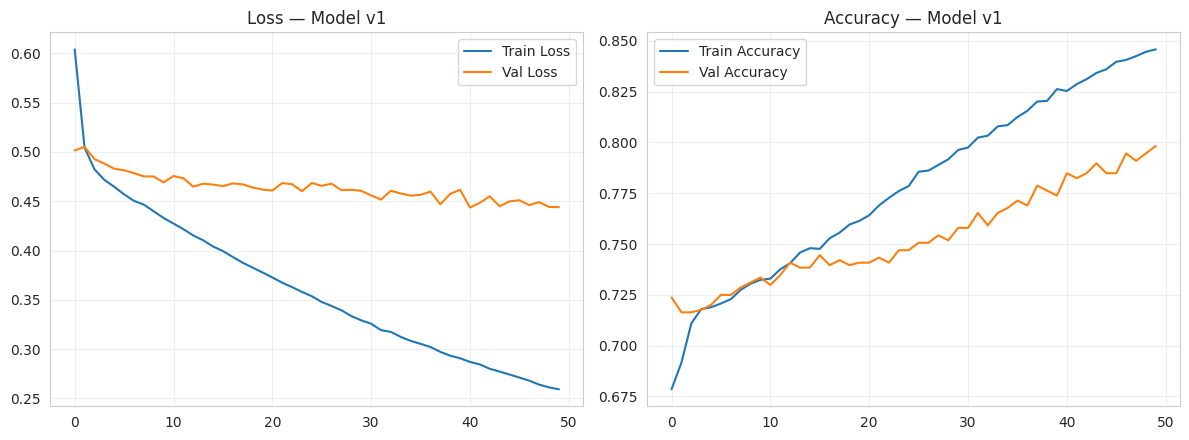

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history_v1.history["loss"], label="Train Loss")
axes[0].plot(history_v1.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss — Model v1"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_v1.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_v1.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy — Model v1"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 31.2 Add Batch Normalization & Dropout — Model v2

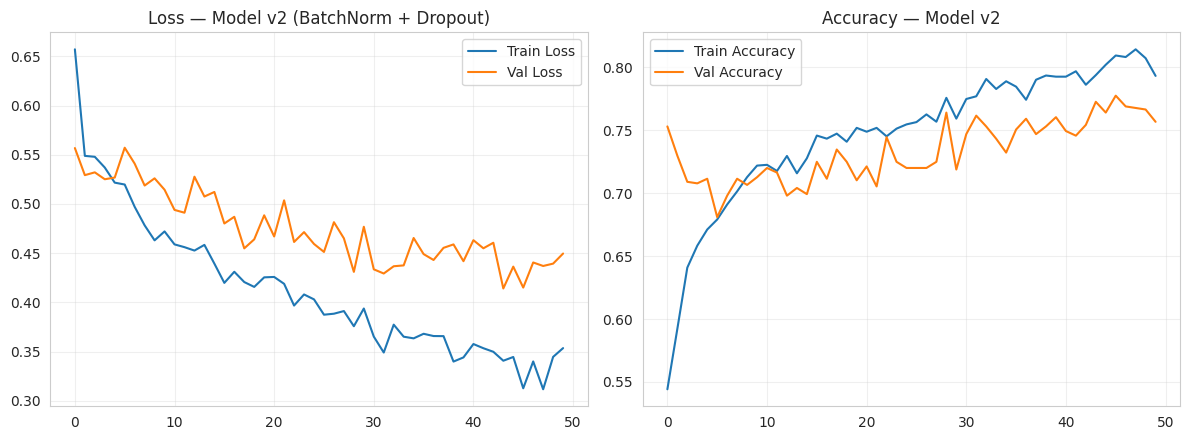

In [57]:
model_v2 = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation="relu"),
    BatchNormalization(), Dropout(0.3),
    Dense(1, activation="sigmoid"),
])
model_v2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_v2 = model_v2.fit(
    X_train_nn_proc, y_train_nn,
    validation_data=(X_val_nn_proc, y_val_nn),
    epochs=50, batch_size=32, class_weight=class_weight, verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history_v2.history["loss"], label="Train Loss")
axes[0].plot(history_v2.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss — Model v2 (BatchNorm + Dropout)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_v2.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_v2.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy — Model v2"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 31.3 Evaluate on the Test Set — Compare to Section 18 Baseline

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
def evaluate_keras_model(model, X_test_proc, y_test, label=""):
    y_proba = model.predict(X_test_proc, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)
    p, r = precision_score(y_test, y_pred), recall_score(y_test, y_pred)
    f1, auc = f1_score(y_test, y_pred), roc_auc_score(y_test, y_proba)
    print(f"--- {label} ---\nPrecision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}  ROC-AUC: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "roc_auc": auc}

results_v1 = evaluate_keras_model(model_v1, X_test_nn_proc, y_test_raw, "Keras v1")
results_v2 = evaluate_keras_model(model_v2, X_test_nn_proc, y_test_raw, "Keras v2 (BatchNorm+Dropout)")

--- Keras v1 ---
Precision: 0.112  Recall: 0.500  F1: 0.183  ROC-AUC: 0.772
--- Keras v2 (BatchNorm+Dropout) ---
Precision: 0.135  Recall: 0.700  F1: 0.227  ROC-AUC: 0.776


### 31.4 Final Comparison — Logistic Regression vs. Random Forest vs. Keras

| Metric | Logistic Regression (§18) | Random Forest (§19) | Keras v1 | Keras v2 |
|---|---|---|---|---|
| Precision | 13.47% | 0.00% | 11.2% | 13.5% |
| Recall | **80.00%** | 0.00% | 50.0% | 70.0% |
| F1-score | 23.05% | 0.00% | 18.3% | 22.7% |
| ROC-AUC | **0.840** | 0.783 | 0.772 | 0.776 |

**Interpretation:** Logistic Regression is the strongest model overall — highest
recall (80.0%) and highest ROC-AUC (0.840) of all four. Random Forest, at its default
0.5 threshold, predicts **zero** stroke cases (0% precision, 0% recall) despite 95.01%
raw accuracy — a textbook case of an imbalance-blind model that looks good on accuracy
alone while being clinically useless. Between the two neural networks, v2
(BatchNorm + Dropout) is clearly the better Keras model (70.0% recall vs. 50.0%, and
higher ROC-AUC), but neither Keras variant beats the class-weighted Logistic Regression
baseline. **Conclusion: the simplest model wins.** On this dataset, `class_weight`
handling matters far more than architectural complexity — Logistic Regression's
explicit imbalance handling outperforms both Random Forest (no rebalancing) and two
neural network architectures. This is a legitimate, documented Sprint 1 finding, not a
shortfall: it directly motivates using threshold tuning or resampling techniques as the
priority for Sprint 2, rather than a deeper network.